# Geographic Customer Analysis
## Understanding Customer Distribution and Regional Patterns

## 1. Imports and Setup

In [91]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geographic mapping
import folium
from folium.plugins import MarkerCluster, HeatMap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## 2. Load Data

In [73]:
# Load customer data
path = "/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets/customer_info.csv"
ci = pd.read_csv(path, index_col='customer_id')


print("Data loaded successfully!")
print(f"Shape: {ci.shape}")

Data loaded successfully!
Shape: (33038, 24)


In [77]:
valid_coords = ci[['latitude', 'longitude']].dropna()
print(f"Total customers: {len(ci):,}")
print(f"Customers with coordinates: {len(valid_coords):,}")
print(f"Missing coordinates: {len(ci) - len(valid_coords):,}")
print(f"Coverage: {len(valid_coords)/len(ci)*100:.1f}%")

Total customers: 33,038
Customers with coordinates: 33,038
Missing coordinates: 0
Coverage: 100.0%


## 3. Basic Geographic Statistics

In [79]:
print("GEOGRAPHIC STATISTICS")

print("\n--- Latitude Statistics ---")
print(f"Minimum: {ci['latitude'].min():.4f}")
print(f"Maximum: {ci['latitude'].max():.4f}")
print(f"Mean: {ci['latitude'].mean():.4f}")
print(f"Std Dev: {ci['latitude'].std():.4f}")

print("\n--- Longitude Statistics ---")
print(f"Minimum: {ci['longitude'].min():.4f}")
print(f"Maximum: {ci['longitude'].max():.4f}")
print(f"Mean: {ci['longitude'].mean():.4f}")
print(f"Std Dev: {ci['longitude'].std():.4f}")

GEOGRAPHIC STATISTICS

--- Latitude Statistics ---
Minimum: 38.6880
Maximum: 38.8237
Mean: 38.7497
Std Dev: 0.0225

--- Longitude Statistics ---
Minimum: -9.2330
Maximum: -9.0357
Mean: -9.1545
Std Dev: 0.0286


## 4. Customer Density Map

fig, ax = plt.subplots(figsize=(14, 10))

hb = ax.hexbin(ci['longitude'], ci['latitude'], 
               gridsize=100, 
               cmap='YlOrRd', 
               bins='log',
               alpha=0.8)

ax.set_title('Customer Density Map (Log Scale)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('Number of Customers (log scale)', fontsize=12)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Spend Analysis by Region

Customers by Region:
        customer_count  longitude
region                           
South             7909       7909
Center           21382      21382
North             3747       3747


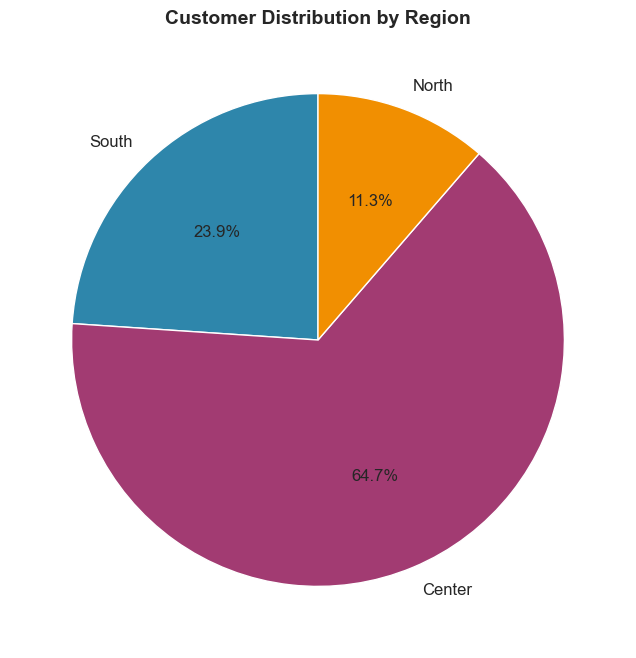

In [85]:
# Create regions based on latitude
ci['region'] = pd.cut(ci['latitude'], bins=3, labels=['South', 'Center', 'North'])

# Calculate statistics by region
region_stats = ci.groupby('region').agg({
    'latitude': 'count',
    'longitude': 'count'
}).rename(columns={'latitude': 'customer_count'})

print("Customers by Region:")
print(region_stats)

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(region_stats['customer_count'], labels=region_stats.index, autopct='%1.1f%%', 
        colors=['#2E86AB', '#A23B72', '#F18F01'], startangle=90)
plt.title('Customer Distribution by Region', fontsize=14, fontweight='bold')
plt.show()

## 6. Average Spend Heatmap by Location

In [90]:
# Calculate center
center_lat = ci['latitude'].mean()
center_lon = ci['longitude'].mean()

# Create map
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='CartoDB positron')

# Add tile layers
folium.TileLayer('openstreetmap').add_to(m)
folium.TileLayer('Stamen Terrain').add_to(m)

# Sample data (to avoid browser crash)
sample_size = min(1000, len(ci))
df_sample = ci.dropna(subset=['latitude', 'longitude']).sample(sample_size)

# Add markers
for idx, row in df_sample.iterrows():
    # Color based on spend (example using groceries)
    spend = row['lifetime_spend_groceries']
    if spend > ci['lifetime_spend_groceries'].median():
        color = 'green'
    else:
        color = 'red'
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"Customer: {idx}<br>Spend: €{spend:,.0f}"
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display map
display(m)

print("Green: Above median spend | Red: Below median spend")

Green: Above median spend | Red: Below median spend
